In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy import stats
from utility import clean_reddit_posts, extract_case_features, extract_linguistic_features

df = pd.read_csv("cleaned_suicidality_dataset.csv", keep_default_na=False, index_col=0)

# EDA Questions

### Main Question: Does the 'Suicidal' label manifest more through emotional vocabulary or through specific grammatical structures (like self-focus and punctuation usage)?

1) Is there a statistically significant difference in the mean negative_emotion score between the two labels?
2) Is there a statistically significant difference in first-person singular pronoun usage between Suicidal and Non-Suicidal posts?
3) 


---

## EDA Question 1: Is there a statistically significant difference in the mean negative_emotion score between the two labels?
<introduction>

To be able to analyze the emotional tone of the data, we can look at the distribution of the `negative_emotion` feature counts for "Suicidal" and "Non-Suicidal" labels.
This helps us understand how prevalent negative emotional language is in each group and whether one label consistently shows higher intensity.
We can begin by comparing group means, then visualize spread and outliers using a boxplot, and finally check statistical significance with an independent-samples test.

In [2]:
# Calculate the mean negative emotion for each label
print(df.groupby('label')['negative_emotion'].mean())

label
Non-Suicidal    0.241190
Suicidal        0.940069
Name: negative_emotion, dtype: float64


/var/folders/2f/bn57x__n17l0rr82f5xx7h680000gn/T/ipykernel_80372/1390600404.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='negative_emotion', palette='coolwarm')


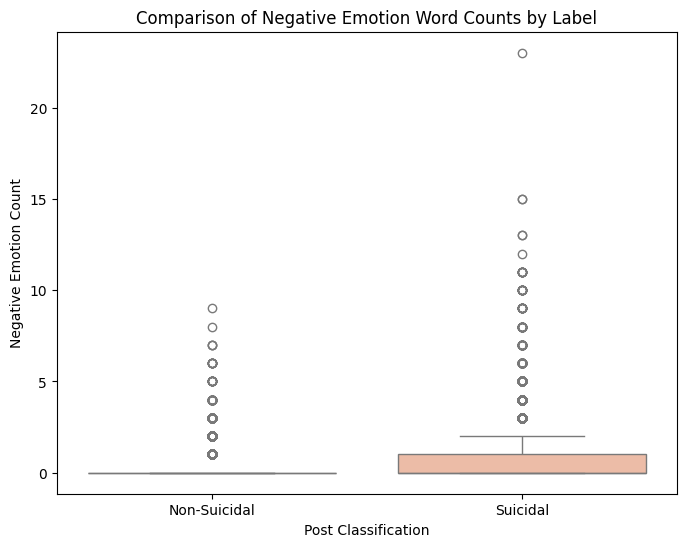

In [ ]:

# Create a boxplot to compare negative_emotion across labels
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='label', y='negative_emotion', palette='coolwarm')

plt.title('Comparison of Negative Emotion Word Counts by Label')
plt.xlabel('Post Classification')
plt.ylabel('Negative Emotion Count')
plt.show()

In [5]:
suicidal_mean = df[df['label'] == 'Suicidal']['negative_emotion']
non_suicidal_mean = df[df['label'] == 'Non-Suicidal']['negative_emotion']

t_stat, p_value = stats.ttest_ind(suicidal_mean, non_suicidal_mean, equal_var=False)

print(f"Welch's t-test statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference")

Welch's t-test statistic: 35.9569
P-value: 0.0000
Result: Statistically significant difference (p < 0.05)


The Welch's t-test showed that there is a statistically significant difference between negative emotion 

---

## EDA Question 2: Is there a statistically significant difference in first-person singular pronoun usage between Suicidal and Non-Suicidal posts?

<introduction>

In [26]:
# Calculate the mean first_person_singular for each label
print("Mean first_person_singular by label:")
print(df.groupby('label')['first_person_singular'].mean())

Mean first_person_singular by label:
label
Non-Suicidal    11.836727
Suicidal        20.680687
Name: first_person_singular, dtype: float64


/var/folders/wy/nfwt2j3n1v11v6kmszqs69cr0000gn/T/ipykernel_26151/4252779587.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='first_person_singular', palette='coolwarm')


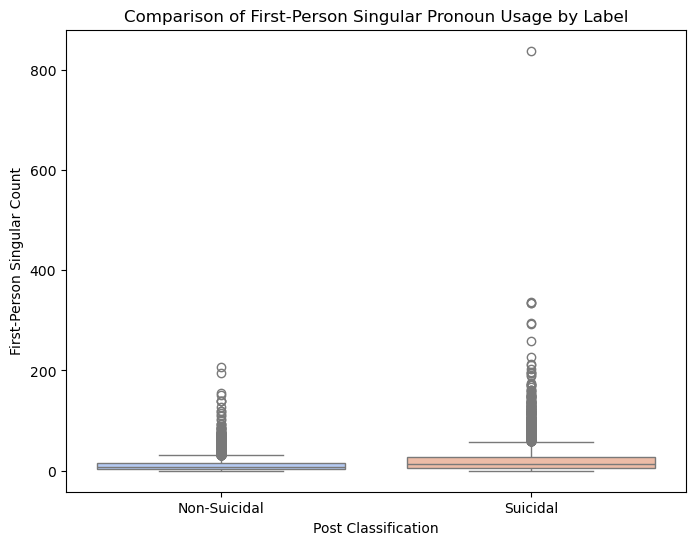

In [27]:
# Boxplot: first_person_singular across labels
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='label', y='first_person_singular', palette='coolwarm')

plt.title('Comparison of First-Person Singular Pronoun Usage by Label')
plt.xlabel('Post Classification')
plt.ylabel('First-Person Singular Count')
plt.show()

In [28]:
suicidal_fp = df[df['label'] == 'Suicidal']['first_person_singular']
non_suicidal_fp = df[df['label'] == 'Non-Suicidal']['first_person_singular']

t_stat, p_value = stats.ttest_ind(suicidal_fp, non_suicidal_fp, equal_var=False)

print(f"Welch's t-test statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference")

Welch's t-test statistic: 26.4571
P-value: 0.0000
Result: Statistically significant difference (p < 0.05)


The Welch's t-test showed that there is a statistically significant difference between first-person 